# **3. ANALYSE DE L'APPARITION CHROLOGIQUE DES THEMES**

In [2]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from tslearn.metrics import dtw, dtw_path
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.manifold import MDS
from tqdm import tqdm

from utils import get_sequence, distance_hamming, plot_alignment, plot_cartographie_texte, plot_cartographie_texte_regroupe

In [3]:
df_chunks = pd.read_excel('data/df_chunks_part2_detailed.xlsx')
df_chunks.head()

,AUTEUR,LANGUE,VILLE,CHUNK_MOTS,NB_MOTS,CHUNK_ID,distance avec les autres villes,types de population,esthétique de la ville,histoire de la toponymie urbaine,...,mosquée,église,synagogue,cimetière et tombes,monuments et vestiges,pyramide,jardin,climat,animaux,plantes et arbres
0,AL YAQUBI,arabe,Le Caire,الغسطاط تعرف بباب اليون وهو الموضع المعروف بال...,50,1,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,AL YAQUBI,arabe,Le Caire,عمرو بن العاص مسجد جامعها ودار امارتها المعروف...,36,2,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,AL YAQUBI,arabe,Le Caire,واسكنه قوما وكتب الى عمر بن الخطاب بذلك فكتب ا...,50,3,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,AL YAQUBI,arabe,Le Caire,لان لكل كورة مدينة مخصوصة بأمر من الامور من مد...,56,4,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,AL YAQUBI,arabe,Le Caire,ومدينة القيس وبها تعل الثياب القيسية والأكسية ...,50,5,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [4]:
# Chargement des themes depuis le fichier texte
with open("data/themes.txt", "r", encoding="utf-8") as f:
    themes = [line.strip() for line in f if line.strip()]

print(themes)

['distance avec les autres villes', 'types de population', 'esthétique de la ville', 'histoire de la toponymie urbaine', 'élement géomorphologique', 'périphérie de ville', 'porte', 'voirie', 'pouvoir', 'palais ; citadelle et château', 'mur et murailles', 'matériaux', 'infrastructure de services', 'eau potable et fontaine', 'pont', 'port et bateau', 'habitation et maison', 'marché', 'richesse de la ville ou du prince', 'impôts et taxes', 'espaces agricoles', 'artisanat', 'mosquée', 'église', 'synagogue', 'cimetière et tombes', 'monuments et vestiges', 'pyramide', 'jardin', 'climat', 'animaux', 'plantes et arbres']


## **3.1. Comparaison entre les auteurs de la chronologie de l'apparition des thèmes**

In [4]:
# Étape 1 — Copie du DataFrame
df = df_chunks.copy()

# Étape 2 — Sélection des colonnes de la 6eme à la 37eme
theme_cols = df.columns[7:38].tolist()

# Étape 3 — Création d’un identifiant de texte unique
df['TEXT_ID'] = df['AUTEUR'] + " - " + df['VILLE']

# Étape 4 — Liste des textes et des thèmes
textes = df['TEXT_ID'].unique()

# Étape 5 — Préparation de la figure



# Étape 6 — Couleurs
colors = plt.get_cmap('tab20', len(themes))
theme_colors = {theme: colors(i) for i, theme in enumerate(themes)}

# Étape 7 — Dessin des frises
for i, theme in enumerate(themes):
    # Créer une nouvelle figure pour chaque thème
    fig, ax = plt.subplots(figsize=(12, len(textes) * 0.2))
    
    ax.set_title(f"Thème : {theme}", loc='center', fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, len(textes))
    ax.set_yticks(np.arange(len(textes)) + 0.5)
    ax.set_yticklabels(textes, fontsize=8)
    ax.invert_yaxis()  # texte le plus ancien en haut
    ax.set_xlabel("------------------------------------------------------------------------------------------------------------------------------>\nProgression dans le texte\n")

    for j, text_id in enumerate(textes):
        chunks = df[df['TEXT_ID'] == text_id].sort_values('CHUNK_ID')
        n_chunks = len(chunks)
        for k, (_, row) in enumerate(chunks.iterrows()):
            if row[theme]:  # si le thème est présent dans ce chunk
                start = k / n_chunks
                width = 1 / n_chunks
                rect = patches.Rectangle((start, j), width, 1, color=theme_colors[theme])
                ax.add_patch(rect)
    # Sauvegarde de l'image avec un nom de fichier qui contient le thème
    plt.tight_layout()
    plt.savefig(f"figures/3-1/chronologie_{theme.replace(' ', '_')}.png", bbox_inches='tight')
    #plt.show() # Décommenter pour afficher les images directement dans le notebook
    plt.close()

## **3.2. Cartographie littéraire de texte sur l'ensemble des thèmes**

In [ ]:
# Génération des visuels pour l'ensemble des textes d'après une fonction
grouped = df_chunks.groupby(['AUTEUR', 'VILLE'])
for (auteur, ville), group in grouped:
    plot_cartographie_texte(df_chunks=df_chunks, themes=themes, auteur=auteur, ville=ville, theme_cols=themes, show=False) #Changer pour 'True' pour afficher les cartographies directement dans le notebook

## **3.3. Cartographie littéraire de texte sur les thèmes regroupés**

In [6]:
# 1. Définition de la typologie (copie de ce qu'on a fait)
typologie_ville = {
    "Identification de la ville": ["histoire de la toponymie urbaine","distance avec les autres villes","esthétique de la ville"],
    "Capitalité de la ville": ["palais ; citadelle et château","impôts et taxes","pouvoir","richesse de la ville ou du prince"],
    "Limites et frontieres urbaines": ["élement géomorphologique","périphérie de ville","mur et murailles","porte"],
    "Circulation et acces": ["voirie","pont","port et bateau"],
    "Habitat et architecture": ["habitation et maison","matériaux"],
    "Infrastructures et services": ["infrastructure de services","eau potable et fontaine"],
    "Activites économiques": ["marché","artisanat","espaces agricoles"],
    "Population": ["types de population"],
    "Religions": ["mosquée","église","synagogue"],
    "Mémoire": ["monuments et vestiges","cimetière et tombes","pyramide"],
    "Nature": ["jardin","animaux","plantes et arbres","climat"]
}

# 2. Créer les colonnes regroupées dans df_chunks (booléens)
for groupe, themes in typologie_ville.items():
    # S'assurer que les colonnes existent dans df_chunks, sinon créer avec False
    existing_themes = [t for t in themes if t in df_chunks.columns]
    if not existing_themes:
        # si aucun thème existe en colonne, on crée la colonne mais False partout
        df_chunks[groupe] = False
    else:
        # Nouvelle colonne à True si au moins un thème du groupe est True
        df_chunks[groupe] = df_chunks[existing_themes].any(axis=1)

# 3. Liste des catégories regroupées (pour la légende et le plotting)
categories_regroupees = list(typologie_ville.keys())


In [ ]:
# Génération des visuels pour l'ensemble des textes d'après une fonction
grouped = df_chunks.groupby(['AUTEUR', 'VILLE'])
for (auteur, ville), group in grouped:
    plot_cartographie_texte_regroupe(df=df_chunks, auteur=auteur, ville=ville, groupes_cols=categories_regroupees, show=False)

## **3.4. Analyse de la similarité thématique entre deux textes grâce à Dynamic Time Warping**

Aligement automatique des séquences (déformation temporelle dynamique)
>La méthode DTW (Dynamic Time Warping) est utilisée pour aligner deux textes décrivant un lieu — Le Cairen par exemple — mais rédigés par des auteurs différents (AL-IDRISI et THETMAR). DTW permet de comparer la structure des textes en tenant compte des différences de rythme, de longueur ou de découpage des segments (chunks). Contrairement à une comparaison linéaire classique, DTW ajuste dynamiquement l’alignement des segments pour faire correspondre des passages similaires, même s’ils apparaissent à des positions différentes ou sont exprimés avec des niveaux de détail variables. Cette approche met ainsi en évidence les correspondances, redondances ou divergences dans la manière dont les deux auteurs traitent le même contenu géographique.


In [ ]:
# Liste des colonnes de thèmes regroupés
groupes_cols = ["distance avec les autres villes","types de population","esthétique de la ville","histoire de la toponymie urbaine",
    "élement géomorphologique", "périphérie de ville","porte","voirie","pouvoir","palais ; citadelle et château","mur et murailles",
    "matériaux","infrastructure de services","eau potable et fontaine","pont","port et bateau","habitation et maison","marché",
    "richesse de la ville ou du prince","impôts et taxes","espaces agricoles","artisanat","mosquée","église","synagogue","cimetière et tombes",
    "monuments et vestiges","pyramide","jardin","climat","animaux","plantes et arbres"]

# Fonction d'extraction d'une séquence multivariée
def get_sequence_ts(df, auteur, ville, groupes_cols):
    df_text = df[(df['AUTEUR'] == auteur) & (df['VILLE'] == ville)].sort_values('CHUNK_ID')
    if df_text.empty:
        return None
    seq = df_text[groupes_cols].astype(int).values
    return seq

In [ ]:
grouped = df_chunks.groupby(['AUTEUR', 'VILLE'])
keys = list(grouped.groups.keys())

In [ ]:
# Alignement DTW multivarié sur chaque combinaison de couples auteur-ville possible
for (auteur1, ville1), (auteur2, ville2) in itertools.combinations(keys, 2):
    seq1 = get_sequence_ts(df_chunks, auteur1, ville1, groupes_cols)
    seq2 = get_sequence_ts(df_chunks, auteur2, ville2, groupes_cols)

    if seq1 is not None and seq2 is not None:
        # Calcul DTW multivarié
        path, dist = dtw_path(seq1, seq2)

        # Visualisation des alignements
        plt.figure(figsize=(12, 5))
        for (i, j) in path:
            plt.plot([i, j], [0, 1], color='lightgray', linewidth=0.5)

        plt.scatter(range(len(seq1)), [0]*len(seq1), label=f'{auteur1} - {ville1}', color='blue')
        plt.scatter(range(len(seq2)), [1]*len(seq2), label=f'{auteur2} - {ville2}', color='green')
        plt.yticks([0, 1], [f'{auteur1} - {ville1}', f'{auteur2} - {ville2}'])
        plt.title(f"Alignement DTW multivarié (Distance = {dist:.2f})")
        plt.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncols=2)
        plt.xlabel("Progression dans les textes (chunks)")
        plt.tight_layout()
        #plt.show()
        plt.savefig(f"figures/3-4-alignement-DTW_multivar/{auteur1}-{ville1}_{auteur2}-{ville2}.png", bbox_inches='tight')
        plt.close()
    else:
        print("L'un des textes est vide.")
        
    if seq1 is None:
        print("Texte 1 vide")
    if seq2 is None:
        print("Texte 2 vide")


In [ ]:
# Matrice de coût accumulé DTW sur chaque combinaison de couples auteur-ville possible
for (auteur1, ville1), (auteur2, ville2) in itertools.combinations(keys, 2):
    # Préparation des séquences (extraites comme avant)
    seq1 = get_sequence_ts(df_chunks, auteur1, ville1, groupes_cols)
    seq2 = get_sequence_ts(df_chunks, auteur2, ville2, groupes_cols)

    # Vérification
    if seq1 is None or seq2 is None:
        raise ValueError("Séquence vide pour l’un des textes.")

    # 1. Distance & chemin optimal
    path, dist = dtw_path(seq1, seq2)

    # 2. Matrice de coût
    cost_matrix = np.zeros((len(seq1), len(seq2)))
    for i in range(len(seq1)):
        for j in range(len(seq2)):
            cost_matrix[i, j] = np.linalg.norm(seq1[i] - seq2[j])

    acc_cost_matrix = np.zeros_like(cost_matrix)
    acc_cost_matrix[0, 0] = cost_matrix[0, 0]
    for i in range(1, len(seq1)):
        acc_cost_matrix[i, 0] = cost_matrix[i, 0] + acc_cost_matrix[i-1, 0]
    for j in range(1, len(seq2)):
        acc_cost_matrix[0, j] = cost_matrix[0, j] + acc_cost_matrix[0, j-1]
    for i in range(1, len(seq1)):
        for j in range(1, len(seq2)):
            acc_cost_matrix[i, j] = cost_matrix[i, j] + min(
                acc_cost_matrix[i-1, j], acc_cost_matrix[i, j-1], acc_cost_matrix[i-1, j-1])

    # 3. Affichage
    plt.figure(figsize=(8, 6))
    plt.imshow(acc_cost_matrix.T, origin='lower', cmap='viridis', aspect='auto')
    path_x, path_y = zip(*path)
    plt.plot(path_x, path_y, color='white', linewidth=2)
    plt.colorbar(label='Coût accumulé')
    plt.title(f"DTW - Matrice de coût accumulé\n{auteur1} - {ville1} vs {auteur2} - {ville2}")
    plt.xlabel(f"Chunks du texte {auteur1} - {ville1} ")
    plt.ylabel(f"Chunks du texte {auteur2} - {ville2} ")
    plt.tight_layout()
    #plt.show()
    plt.savefig(f"figures/3-4_matrice-cout-accu/{auteur1}-{ville1}_{auteur2}-{ville2}.png", bbox_inches='tight')
    plt.close()


In [42]:
def compute_dtw_distance_matrix(df, theme_cols):
    text_ids = df['AUTEUR'] + "\n" + df['VILLE']
    unique_ids = text_ids.unique()
    n = len(unique_ids)

    dist_matrix = np.zeros((n, n))

    for i in tqdm(range(n)):
        id1 = unique_ids[i]
        auteur1, ville1 = id1.split('\n')
        seq1 = get_sequence_ts(df, auteur1, ville1, theme_cols)

        for j in range(i + 1, n):
            id2 = unique_ids[j]
            auteur2, ville2 = id2.split('\n')
            seq2 = get_sequence_ts(df, auteur2, ville2, theme_cols)

            if seq1 is not None and seq2 is not None:
                d = dtw(seq1, seq2)
                dist_matrix[i, j] = d
                dist_matrix[j, i] = d  # symétrie

    return pd.DataFrame(dist_matrix, index=unique_ids, columns=unique_ids)

dist_df = compute_dtw_distance_matrix(df_chunks, groupes_cols)


100%|██████████| 27/27 [00:00<00:00, 92.30it/s]


In [43]:
dist_df

,AL YAQUBI\nLe Caire,IBN RUSTAH\nLe Caire,AL-MASUDI\nLe Caire,IBN HAWQAL\nCordoue,IBN HAWQAL\nPalerme,IBN HAWQAL\nLe Caire,AL-MUQADDASI\nLe Caire,AL-MUQADDASI\nPalerme,AL-MUQADDASI\nCordoue,NAṢIR-I KHUSRAW\nLe Caire,...,BENJAMIN DE TUDELE\nLe Caire,GAUILLAUME DE TYR\nLe Caire,IBN JUBAYR\nLe Caire,IBN JUBAYR\nPalerme,THETMAR\nLe Caire,JACQUES DE VITRY\nLe Caire,OLIVIER\nLe Caire,VINCENT DE BEAUVAIS\nLe Caire,IBN SAID\nLe Caire,AL-HIMYARI\nCordoue
AL YAQUBI\nLe Caire,0.000000,8.246211,4.795832,8.426150,11.747340,8.124038,18.055470,7.745967,6.082763,17.832555,...,9.273618,5.656854,18.303005,8.888194,7.071068,7.483315,7.141428,6.324555,11.832160,13.076697
IBN RUSTAH\nLe Caire,8.246211,0.000000,7.280110,9.591663,11.445523,8.366600,16.462078,9.380832,8.124038,17.464249,...,9.055385,7.745967,17.204651,8.888194,8.124038,8.426150,8.246211,7.874008,12.649111,11.916375
AL-MASUDI\nLe Caire,4.795832,7.280110,0.000000,8.485281,10.440307,7.141428,16.492423,4.123106,3.741657,16.941074,...,7.937254,3.605551,16.733201,7.874008,6.480741,6.164414,6.164414,5.196152,12.083046,11.445523
IBN HAWQAL\nCordoue,8.426150,9.591663,8.485281,0.000000,11.489125,9.539392,16.431677,10.583005,7.681146,16.278821,...,9.591663,7.280110,16.552945,9.433981,9.110434,9.165151,9.000000,9.055385,11.704700,11.618950
IBN HAWQAL\nPalerme,11.747340,11.445523,10.440307,11.489125,0.000000,11.489125,16.492423,12.961481,10.954451,17.521415,...,11.135529,10.535654,16.217275,11.401754,11.224972,11.618950,10.954451,11.135529,12.961481,12.328828
IBN HAWQAL\nLe Caire,8.124038,8.366600,7.141428,9.539392,11.489125,0.000000,18.110770,8.485281,7.615773,19.104973,...,9.327379,7.348469,18.574176,9.165151,8.306624,8.366600,7.810250,7.745967,12.961481,12.922848
AL-MUQADDASI\nLe Caire,18.055470,16.462078,16.492423,16.431677,16.492423,18.110770,0.000000,21.470911,16.613248,18.574176,...,16.522712,16.370706,18.303005,16.822604,16.822604,16.552945,16.643317,17.748239,16.522712,16.031220
AL-MUQADDASI\nPalerme,7.745967,9.380832,4.123106,10.583005,12.961481,8.485281,21.470911,0.000000,4.795832,22.494444,...,11.135529,5.567764,22.338308,10.392305,8.660254,9.000000,7.937254,7.416198,14.866069,14.832397
AL-MUQADDASI\nCordoue,6.082763,8.124038,3.741657,7.681146,10.954451,7.615773,16.613248,4.795832,0.000000,16.186414,...,8.426150,4.242641,16.370706,8.426150,7.141428,7.141428,6.708204,5.916080,11.000000,11.135529
NAṢIR-I KHUSRAW\nLe Caire,17.832555,17.464249,16.941074,16.278821,17.521415,19.104973,18.574176,22.494444,16.186414,0.000000,...,16.970563,16.062378,19.313208,17.549929,17.748239,17.349352,17.549929,17.492856,17.349352,16.401219


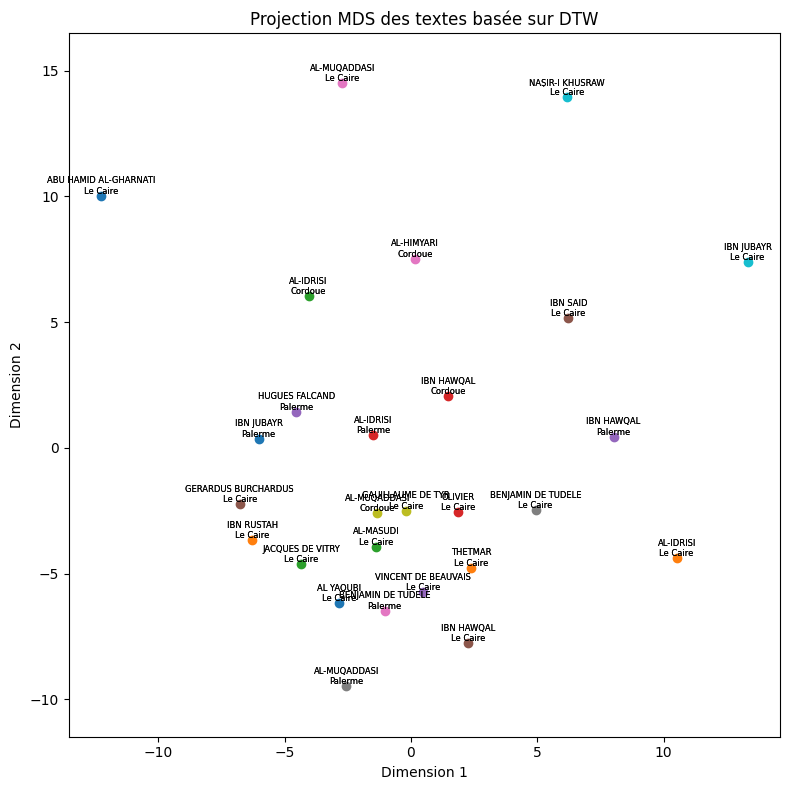

<Figure size 640x480 with 0 Axes>

In [44]:
# Génération de la projection MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(dist_df.values)

plt.figure(figsize=(8, 8))
for i, label in enumerate(dist_df.index):
    plt.scatter(coords[i, 0], coords[i, 1], label=label)
    plt.annotate(label, (coords[i, 0], coords[i, 1]), fontsize=6, ha='center', va='bottom')

    plt.text(coords[i, 0], coords[i, 1], label, fontsize=6, ha='center', va='bottom')

plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title("Projection MDS des textes basée sur DTW")
plt.axis('equal')
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()
plt.savefig(f"figures/3-4_projection-MDS-DTW.png", bbox_inches='tight')